In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 清洗：年龄分组填充中位数
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# 特征：家庭规模和称谓（和昨天一样）
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Other')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("数据准备完毕，形状：", df.shape)

数据准备完毕，形状： (891, 14)


In [4]:
# 一：用 crosstab 看人数交叉表
# 把 'Sex' 放在行上，'Pclass' 放在列上，计算出来默认就是不同组合的个数
cross_tab = pd.crosstab(index=df['Sex'], columns=df['Pclass'])
print("===== 1. 各性别/客舱等级总人数 =====")
print(cross_tab)

===== 1. 各性别/客舱等级总人数 =====
Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  347


In [5]:
cross_tab_survived = pd.crosstab(index=df['Sex'], 
                                 columns=[df['Pclass'], df['Survived']])
print("\n===== 2. 各性别/客舱等级的存活与死亡人数 =====")
print(cross_tab_survived)


===== 2. 各性别/客舱等级的存活与死亡人数 =====
Pclass     1       2        3    
Survived   0   1   0   1    0   1
Sex                              
female     3  91   6  70   72  72
male      77  45  91  17  300  47


In [6]:
# 接下来画图，我们用更直观的“分组柱状图”
# 首先，计算各个性别和客舱等级组合下的存活率
# unstack() 是把表格旋转一下，让数据更好画图
survival_rate = pd.crosstab(index=df['Sex'], columns=df['Pclass'], 
                            values=df['Survived'], aggfunc='mean')
print("\n===== 3. 各性别/客舱等级存活率 =====")
print(survival_rate)



===== 3. 各性别/客舱等级存活率 =====
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


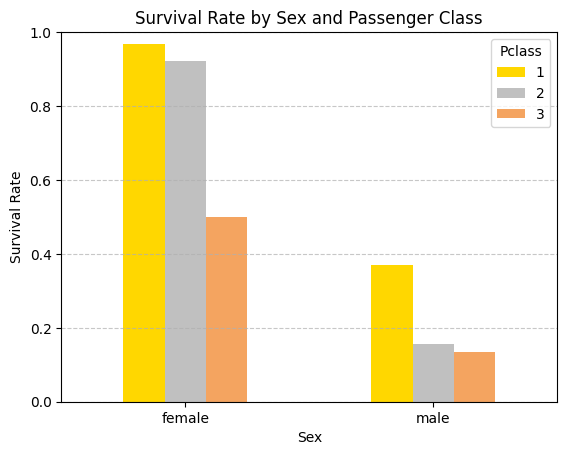

In [7]:
# 画图：存活率的柱状图
survival_rate.plot(kind='bar', color=['gold', 'silver', 'sandybrown'])
plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # 存活率在0到1之间
plt.xticks(rotation=0) # 让x轴标签不旋转
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#  wow  